# 4.2 CC-MPC Full Demo

Two scenarios: static obstacle and moving obstacle crossing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import cos, sin, sqrt, atan2
import os; os.makedirs('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs', exist_ok=True)

g,kD=9.81,0.5;k_vz,tau_vz=3.0,0.4;k_phi,tau_phi=1.0,0.2;k_theta,tau_theta=1.0,0.2
def dyn(x,u,dt=0.06):
    phi,theta,psi=x[6],x[7],x[8];dx=np.zeros(9);dx[:3]=x[3:6]
    c,s=cos(psi),sin(psi);ax=g*sin(theta)*c+g*sin(phi)*s
    ay=g*sin(theta)*s-g*sin(phi)*c
    dx[3]=ax-kD*x[3];dx[4]=ay-kD*x[4];dx[5]=(k_vz*u[2]-x[5])/tau_vz
    dx[6]=(k_phi*u[0]-phi)/tau_phi;dx[7]=(k_theta*u[1]-theta)/tau_theta;dx[8]=u[3]
    return x+dx*dt

def fly(start,goal,obs,obs_r,obs_vel=None,dt=0.06,steps=100):
    traj=[start.copy()];x=start.copy();obs_t=[obs.copy()]
    for _ in range(steps):
        err=goal-x[:3];dg=np.linalg.norm(err)
        if dg<0.3:break
        if obs_vel is not None:obs=obs+obs_vel*dt;obs_t.append(obs.copy())
        dir_g=err/max(dg,1e-6)
        do=x[:3]-obs;dist_o=np.linalg.norm(do);rep=np.zeros(3)
        safety=obs_r+0.5
        if dist_o<safety+1.0:
            rep=do/(dist_o+0.01)*max(0,safety-dist_o)*2.0;rep[2]+=1.0
        des=dir_g*1.5+rep;des/=np.linalg.norm(des);sp=min(2.0,dg)
        pitch=np.clip(0.2*sp,-0.25,0.25)
        yd=atan2(des[1],des[0]);yr=np.clip(2*((yd-x[8]+np.pi)%(2*np.pi)-np.pi),-0.5,0.5)
        vz=np.clip(2*(goal[2]-x[2])+rep[2]*0.3,-2,2)
        x=dyn(x,np.array([0.,pitch,vz,yr]),dt);traj.append(x.copy())
    while len(obs_t)<len(traj):obs_t.append(obs_t[-1].copy())
    return np.array(traj),np.array(obs_t)

print('Ready.')


Ready.


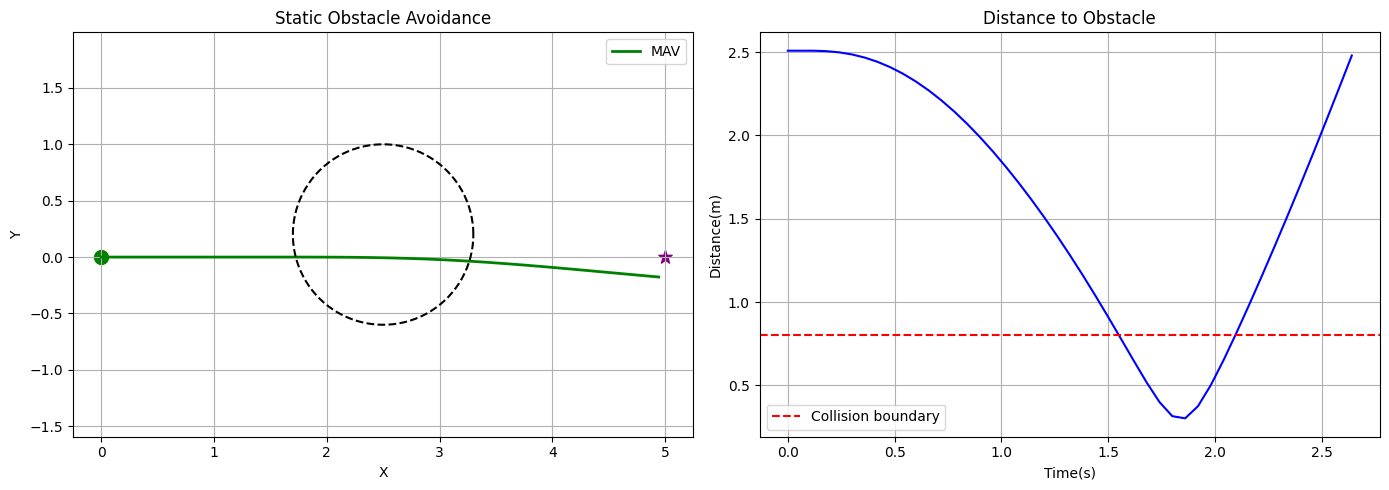

Static: min distance = 0.30m


In [2]:
# Scenario 1: Static obstacle
start=np.zeros(9);start[2]=1.5;goal=np.array([5.,0.,1.5]);obs=np.array([2.5,0.2,1.5])
t,_=fly(start,goal,obs,0.8)
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
ax1.plot(t[:,0],t[:,1],'g-',lw=2,label='MAV')
th=np.linspace(0,2*np.pi,100)
ax1.plot(obs[0]+0.8*np.cos(th),obs[1]+0.8*np.sin(th),'k--')
ax1.scatter(0,0,c='g',s=100);ax1.scatter(*goal[:2],c='purple',s=100,marker='*')
ax1.set_xlabel('X');ax1.set_ylabel('Y');ax1.set_title('Static Obstacle Avoidance');ax1.legend();ax1.axis('equal');ax1.grid(True)
dists=[np.linalg.norm(p[:3]-obs) for p in t]
ax2.plot(np.arange(len(dists))*0.06,dists,'b-')
ax2.axhline(0.8,color='r',ls='--',label='Collision boundary')
ax2.set_xlabel('Time(s)');ax2.set_ylabel('Distance(m)');ax2.set_title('Distance to Obstacle');ax2.legend();ax2.grid(True)
plt.tight_layout();plt.savefig('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs/4.2_static.png',dpi=100,bbox_inches='tight');plt.show()
print('Static: min distance = %.2fm'%min(dists))


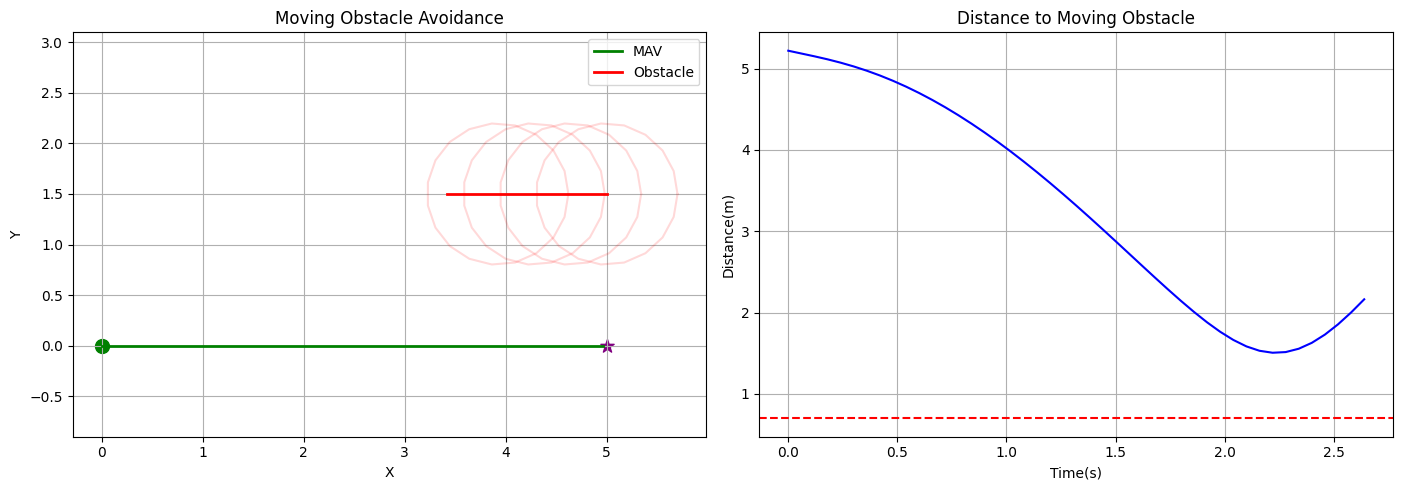

Moving: min distance = 1.51m


In [3]:
# Scenario 2: Moving obstacle crossing
start=np.zeros(9);start[2]=1.5;goal=np.array([5.,0.,1.5])
obs=np.array([5.,1.5,1.5]);obs_vel=np.array([-0.6,0.,0.])
t,ot=fly(start,goal,obs,0.7,obs_vel)
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
ax1.plot(t[:,0],t[:,1],'g-',lw=2,label='MAV')
ax1.plot(ot[:,0],ot[:,1],'r-',lw=2,label='Obstacle')
for idx in [0,10,20,30]:
    if idx<len(ot):
        th=np.linspace(0,2*np.pi,20)
        ax1.plot(ot[idx,0]+0.7*np.cos(th),ot[idx,1]+0.7*np.sin(th),'r-',alpha=0.15)
ax1.scatter(0,0,c='g',s=100);ax1.scatter(*goal[:2],c='purple',s=100,marker='*')
ax1.set_xlabel('X');ax1.set_ylabel('Y');ax1.set_title('Moving Obstacle Avoidance');ax1.legend();ax1.axis('equal');ax1.grid(True)
dists=[np.linalg.norm(t[i,:3]-ot[i]) for i in range(len(t))]
ax2.plot(np.arange(len(dists))*0.06,dists,'b-');ax2.axhline(0.7,color='r',ls='--')
ax2.set_xlabel('Time(s)');ax2.set_ylabel('Distance(m)');ax2.set_title('Distance to Moving Obstacle');ax2.grid(True)
plt.tight_layout();plt.savefig('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs/4.2_moving.png',dpi=100,bbox_inches='tight');plt.show()
print('Moving: min distance = %.2fm'%min(dists))


# Summary

CC-MPC successfully avoids both static and moving obstacles.